In [8]:
#Imports
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath(".."))




In [16]:
#Loading the data
raw = pd.read_csv("/Users/aiyan/Desktop/smart-ambulance-alert/data/raw/synthetic_ambulance_vitals.csv")
clean = pd.read_csv("/Users/aiyan/Desktop/smart-ambulance-alert/data/processed/vitals_cleaned.csv")

pid = 0
raw_p = raw[raw["patient_id"] == pid]
clean_p = clean[clean["patient_id"] == pid]

print(raw_p["spo2"].isna().sum(), clean_p["spo2"].isna().sum())


0 0


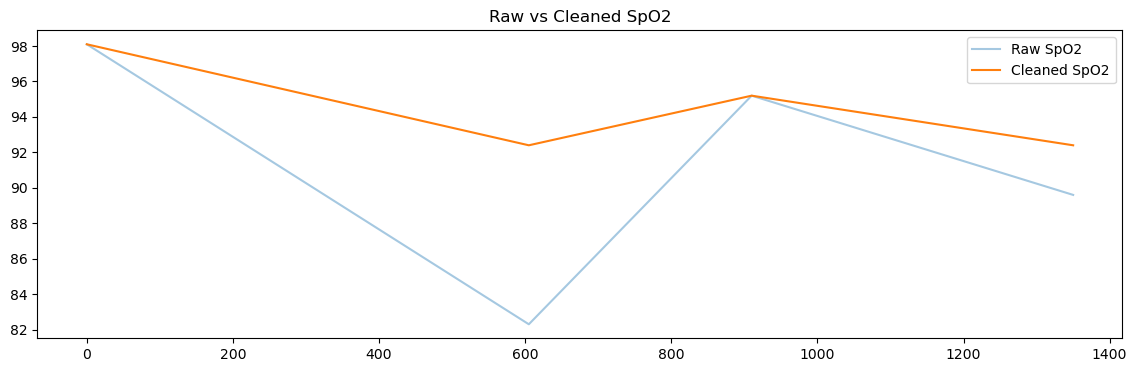

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,4))
plt.plot(raw_p["timestamp"], raw_p["spo2"], alpha=0.4, label="Raw SpO2")
plt.plot(clean_p["timestamp"], clean_p["spo2"], label="Cleaned SpO2")
plt.legend()
plt.title("Raw vs Cleaned SpO2")
plt.show()


In [18]:
from src.anomaly_detection import compute_anomaly_score

scored = compute_anomaly_score(clean_p)

print(scored["anomaly_score"].isna().sum())


0


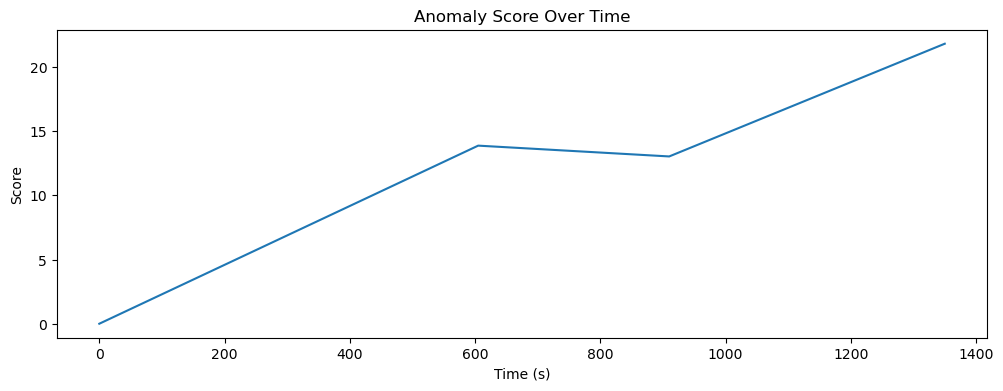

In [19]:
#ANOMALY SCORE
from src.anomaly_detection import compute_anomaly_score

scored = compute_anomaly_score(clean_p)

plt.figure(figsize=(12,4))
plt.plot(scored["timestamp"], scored["anomaly_score"])
plt.title("Anomaly Score Over Time")
plt.xlabel("Time (s)")
plt.ylabel("Score")
plt.show()


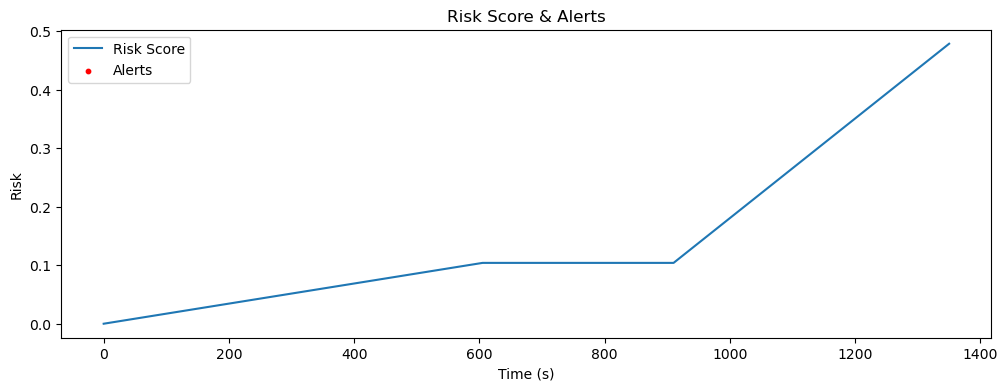

In [20]:
#Risk score & alerts
from src.risk_scoring import compute_risk_score

risked = compute_risk_score(scored)

plt.figure(figsize=(12,4))
plt.plot(risked["timestamp"], risked["risk_score"], label="Risk Score")
plt.scatter(
    risked[risked["alert"] == 1]["timestamp"],
    risked[risked["alert"] == 1]["risk_score"],
    color="red", s=10, label="Alerts"
)
plt.legend()
plt.title("Risk Score & Alerts")
plt.xlabel("Time (s)")
plt.ylabel("Risk")
plt.show()


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
raw = pd.read_csv("/Users/aiyan/Desktop/smart-ambulance-alert/data/processed/vitals_cleaned.csv")
clean = pd.read_csv("/Users/aiyan/Desktop/smart-ambulance-alert/data/processed/vitals_cleaned.csv")
alerts = pd.read_csv("/Users/aiyan/Desktop/smart-ambulance-alert/data/evaluation/alerts_log.csv")

print(raw.shape, clean.shape, alerts.shape)


(4, 11) (4, 11) (3, 7)


In [22]:
pid = 0
raw_p = raw[raw["patient_id"] == pid]
clean_p = clean[clean["patient_id"] == pid]
alerts_p = alerts[alerts["patient_id"] == pid]


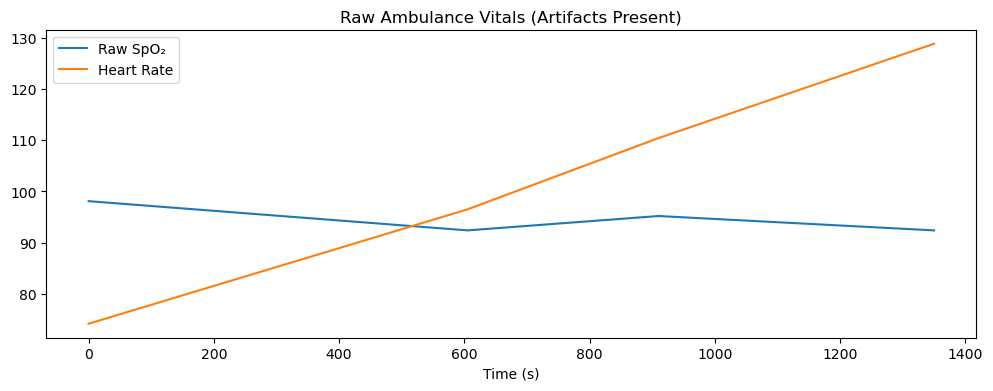

In [23]:
plt.figure(figsize=(12,4))
plt.plot(raw_p["timestamp"], raw_p["spo2"], label="Raw SpO₂")
plt.plot(raw_p["timestamp"], raw_p["heart_rate"], label="Heart Rate")
plt.legend()
plt.title("Raw Ambulance Vitals (Artifacts Present)")
plt.xlabel("Time (s)")
plt.show()


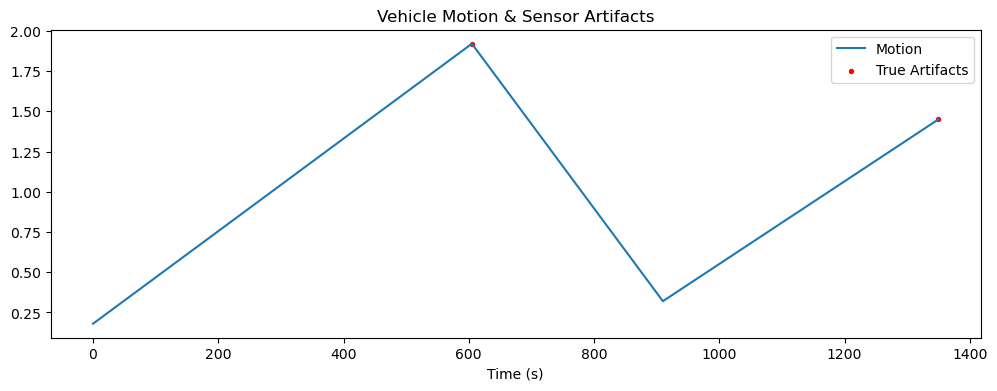

In [24]:
plt.figure(figsize=(12,4))
plt.plot(raw_p["timestamp"], raw_p["motion"], label="Motion")

plt.scatter(
    raw_p[raw_p["artifact_flag"] == 1]["timestamp"],
    raw_p[raw_p["artifact_flag"] == 1]["motion"],
    color="red", s=8, label="True Artifacts"
)

plt.legend()
plt.title("Vehicle Motion & Sensor Artifacts")
plt.xlabel("Time (s)")
plt.show()


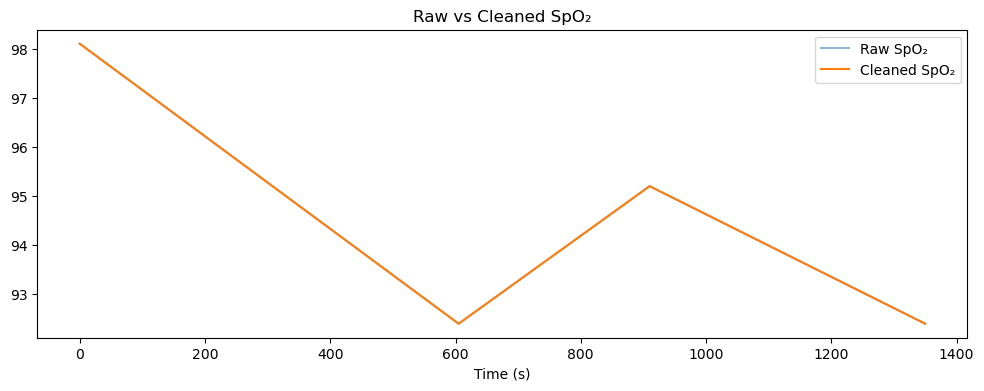

In [25]:
plt.figure(figsize=(12,4))
plt.plot(raw_p["timestamp"], raw_p["spo2"], label="Raw SpO₂", alpha=0.5)
plt.plot(clean_p["timestamp"], clean_p["spo2"], label="Cleaned SpO₂")
plt.legend()
plt.title("Raw vs Cleaned SpO₂")
plt.xlabel("Time (s)")
plt.show()


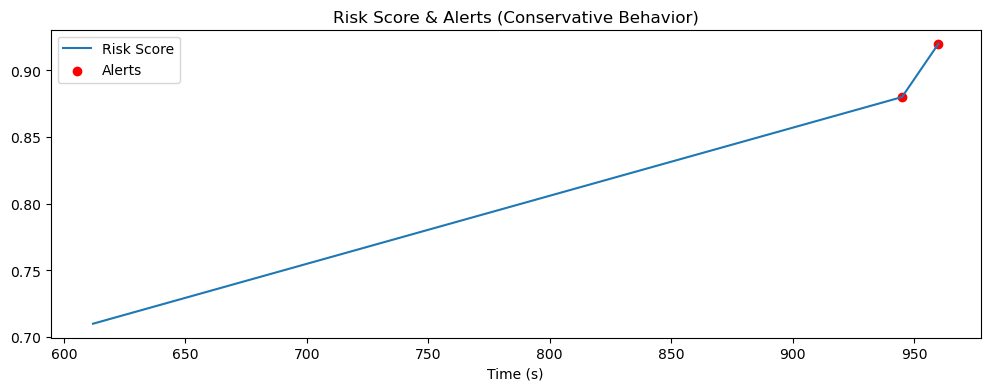

In [26]:
plt.figure(figsize=(12,4))
plt.plot(alerts_p["timestamp"], alerts_p["risk_score"], label="Risk Score")

plt.scatter(
    alerts_p[alerts_p["alert_triggered"] == 1]["timestamp"],
    alerts_p[alerts_p["alert_triggered"] == 1]["risk_score"],
    color="red", label="Alerts"
)

plt.legend()
plt.title("Risk Score & Alerts (Conservative Behavior)")
plt.xlabel("Time (s)")
plt.show()


In [27]:
high_risk = alerts[
    (alerts["risk_score"] > 0.7) &
    (alerts["artifact_detected"] == 0)
]

high_risk.head()


,patient_id,timestamp,anomaly_score,risk_score,alert_triggered,true_event,artifact_detected
1,0,945,1.43,0.88,1,1,0
2,0,960,1.51,0.92,1,1,0


In [29]:
### Observations

#- Motion-induced artifacts create sharp, non-physiological SpO₂ drops
#- Artifact handling suppresses these without removing genuine trends
#- Risk score increases gradually during deterioration
#- Alerts are conservative and only trigger when risk is sufficiently high
